# Integrate RNA & ATAC for in silico ChIP on integrated pseudo-unimodal scRNA & scATAC

In [1]:
###################
## Load packages
###################
here::i_am("revision/RNA_ATAC_integration_metacells/00_getGeneScoreMatrix_Distal.ipynb")

suppressPackageStartupMessages({
    library(scran)
    library(scater)
    library(Seurat)
    library(ArchR)
})
source(here::here("settings.R"))
source(here::here("utils.R"))
source(here::here("revision/insilico_chip/utils.R"))


here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/code


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,

In [2]:
###################
## I/O
###################
io = list()
io$basedir = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/'

## Single-cell
io$metacell_folder = file.path(io$basedir, '/results/rna/metacells/all_cells/rna_atac/')
io$RNA_sce = file.path(io$basedir,"data/processed/rna/SingleCellExperiment.rds")
io$RNA_metadata = file.path(io$basedir,"results/rna/mapping/sample_metadata_after_mapping.txt.gz")
#io$ATAC_GeneScores_sce = file.path(io$basedir,"data/processed/atac/archR/Matrices/GeneScoreMatrix_distal_summarized_experiment.rds")
#io$ATAC_peaks_sce = file.path(io$basedir,"data/processed/atac/archR/Matrices/PeakMatrix_summarized_experiment.rds")
io$archr_directory <- file.path(io$basedir,"data/processed/atac/archR")
io$ATAC_metadata <- file.path(io$basedir,"/results/atac/archR/qc/sample_metadata_after_qc.txt.gz")
io$ATAC_LSI = file.path(io$basedir, 'results/atac/archR/dimensionality_reduction/cells/PeakMatrix/remove_ExE_cells_False/batch_correction_None/lsi_nfeatures25000_ndims50.txt.gz')

#
io$motifmatcher = file.path(io$basedir, "data/processed/atac/archR/Annotations/CISBP-Scores.rds")
io$motif2gene = file.path(io$basedir, "data/processed/atac/archR/Annotations/CISBP_motif2gene.txt.gz")
io$background_peaks = file.path(io$basedir,"/data/processed/atac/archR/Background-Peaks.rds")

# outdir
io$outdir = file.path(io$basedir, 'results/revisions/whole_atlas_unimodal/')
dir.create(io$outdir, showWarnings=F, recursive=T)

In [3]:
#######################
## RNA
#######################

# Load SingleCellExperiment
rna_metadata <- fread(io$RNA_metadata) %>%
  .[pass_rnaQC==TRUE & doublet_call==FALSE]

rna.sce <- load_SingleCellExperiment(io$RNA_sce, cells=rna_metadata$cell, normalise = TRUE)
colnames(rna.sce) = paste('RNA_', colnames(rna.sce))

rna.seurat = as.Seurat(rna.sce)
# Find variable features
rna.seurat <- FindVariableFeatures(rna.seurat, nfeatures = 5000)
genes_keep = VariableFeatures(object = rna.seurat)

In [7]:
#######################
## ATAC
#######################

sample_metadata <- fread(io$ATAC_metadata) %>%
  .[doublet_call==FALSE & pass_atacQC==TRUE & !sample %in% c('E8.5_CRISPR_T_KO','E8.5_CRISPR_T_WT')]

setwd(io$archr_directory)

addArchRGenome("mm10")
addArchRThreads(threads = 24) 

ArchRProject <- loadArchRProject(io$archr_directory)

# Subset to cells that pass QC
ArchRProject <- ArchRProject[sample_metadata$cell]



Setting default genome to Mm10.

Setting default number of Parallel threads to 24.

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\_

In [ ]:
# # Get ATAC LSI --> this is not working for adding imputation
# ATAC_LSI = fread(io$ATAC_LSI) %>% as.data.frame() %>%
#     tibble::column_to_rownames('cell') %>% as.matrix()
# ArchRProject@reducedDims$IterativeLSI$svd = ATAC_LSI

# Recalculate LSI
ArchRProject = addIterativeLSI(
                ArchRProj = ArchRProject,
                useMatrix = "PeakMatrix",
                name = "IterativeLSI",
                varFeatures = 50000,
                dimsToUse = 1:50,
                force=TRUE)  


# Add Impute weights
ArchRProject = addImputeWeights(
                              ArchRProj = ArchRProject,
                              reducedDims = "IterativeLSI")

In [8]:
# Get GeneScoreMatrix
GeneScoreMatrix_distal.se = getMatrixFromProject(
  ArchRProj = ArchRProject,
  useMatrix = "GeneScoreMatrix_distal",
  useSeqnames = NULL,
  verbose = FALSE,
  binarize = FALSE,
  threads = getArchRThreads(),
  logFile = createLogFile("getMatrixFromProject")
)

rownames(GeneScoreMatrix_distal.se) = rowData(GeneScoreMatrix_distal.se)$name

# Subset to variable features
genes_keep = intersect(genes_keep, rownames(GeneScoreMatrix_distal.se))
GeneScoreMatrix_distal.se = GeneScoreMatrix_distal.se[genes_keep,]

In [9]:
# Impute weights on GeneScoreMatrix
GeneScoreMatrix_distal_imputed.mtx = imputeMatrix(
                                          mat = assay(GeneScoreMatrix_distal.se),
                                          imputeWeights = getImputeWeights(ArchRProject),
                                          threads = getArchRThreads(),
                                          verbose = FALSE,
                                          logFile = createLogFile("imputeMatrix")
)

# Log normalise imputed matrix
# Not sure if this is the best way to normalise the data
atac.mtx <- log(GeneScoreMatrix_distal_imputed.mtx + 1)

# Check in ArchR again how they perform imputedmatrix

Checking Inputs...

ArchR logging to : ArchRLogs/ArchR-addIterativeLSI-255bf4ef42c27-Date-2023-04-14_Time-10-24-09.log
If there is an issue, please report to github with logFile!

2023-04-14 10:24:15 : Computing Total Across All Features, 0.084 mins elapsed.

2023-04-14 10:24:18 : Computing Top Features, 0.14 mins elapsed.

###########
2023-04-14 10:24:20 : Running LSI (1 of 2) on Top Features, 0.175 mins elapsed.
###########

2023-04-14 10:24:20 : Sampling Cells (N = 10004) for Estimated LSI, 0.177 mins elapsed.

2023-04-14 10:24:20 : Creating Sampled Partial Matrix, 0.177 mins elapsed.

2023-04-14 10:24:39 : Computing Estimated LSI (projectAll = FALSE), 0.487 mins elapsed.

2023-04-14 10:25:42 : Identifying Clusters, 1.536 mins elapsed.

2023-04-14 10:25:57 : Identified 6 Clusters, 1.79 mins elapsed.

2023-04-14 10:25:57 : Saving LSI Iteration, 1.79 mins elapsed.

2023-04-14 10:26:15 : Creating Cluster Matrix on the total Group Features, 2.097 mins elapsed.

2023-04-14 10:26:27 : Com

In [10]:
colnames(atac.mtx) = paste0('ATAC_', colnames(atac.mtx))

In [5]:
rm(GeneScoreMatrix_distal.se)
rm(GeneScoreMatrix_distal_imputed.mtx)

Warning message in rm(GeneScoreMatrix_distal.se):
“object 'GeneScoreMatrix_distal.se' not found”
Warning message in rm(GeneScoreMatrix_distal_imputed.mtx):
“object 'GeneScoreMatrix_distal_imputed.mtx' not found”


In [11]:
saveRDS(atac.mtx, file.path(io$outdir, 'atac_mtx.rds'))

In [4]:
atac.mtx = readRDS(file.path(io$outdir, 'atac_mtx.rds'))

In [5]:
# Create Seurat object for ATAC
atac.seurat = CreateSeuratObject(
        atac.mtx,
        project = "multiome_ATAC",
        assay = "ATAC"
    )

# Subset RNA & ATAC to same genes
genes = intersect(rownames(atac.seurat), rownames(rna.seurat))
rna.seurat = rna.seurat[genes,]
atac.seurat = atac.seurat[genes,]

# Scale both 
rna.seurat <- ScaleData(rna.seurat, features = VariableFeatures(object = rna.seurat))
atac.seurat <- ScaleData(atac.seurat, features = VariableFeatures(object = rna.seurat))

Centering and scaling data matrix

Centering and scaling data matrix



In [6]:
VariableFeatures(object = atac.seurat) = VariableFeatures(object = rna.seurat)

In [7]:
# Seurat multicore
library(future)
plan("multicore", workers = 12)
options(future.globals.maxSize = 50000 * 1024^2) # Use up to 50 Gb of RAM

# CCA integration
CCA = RunCCA(
  rna.seurat,
  atac.seurat,
  standardize = TRUE,
  num.cc = 35
)

Warning message in RunCCA.Seurat(rna.seurat, atac.seurat, standardize = TRUE, num.cc = 35):
“Running CCA on different assays”
Running CCA

Merging objects

Warning message:
“The following arguments are not used: standardize”


In [9]:
CCA_embeddings = CCA@reductions$cca@cell.embeddings

In [10]:
# create umap
CCA_umap = uwot::umap(CCA_embeddings, n_neighbors = 40, min_dist = 0.4, metric="cosine", verbose=FALSE)
CCA_umap = as.data.table(CCA_umap, keep.rownames=T) %>%
    setnames(c('cell', 'UMAP1', 'UMAP2')) %>%
    .[,`:=`(modality=cell %>% str_split('_') %>% map_chr(1),
            cell=paste0(cell %>% str_split('_') %>% map_chr(2),
                       '_',
                       cell %>% str_split('_') %>% map_chr(3)))]
head(CCA_umap)

cell,UMAP1,UMAP2,modality
<chr>,<dbl>,<dbl>,<chr>
E7.5_rep1#AAACAGCCAAACTCAT-1,0.2518106,-1.3684953,RNA
E7.5_rep1#AAACAGCCACAACCTA-1,10.2013558,-7.9615163,RNA
E7.5_rep1#AAACAGCCATCCTGAA-1,0.9519950,2.1390725,RNA
E7.5_rep1#AAACAGCCATGCTATG-1,0.8729462,-1.5740766,RNA
E7.5_rep1#AAACATGCAACCTGGT-1,12.4600161,9.5698534,RNA
E7.5_rep1#AAACATGCAATGAATG-1,-1.3377738,0.4408181,RNA


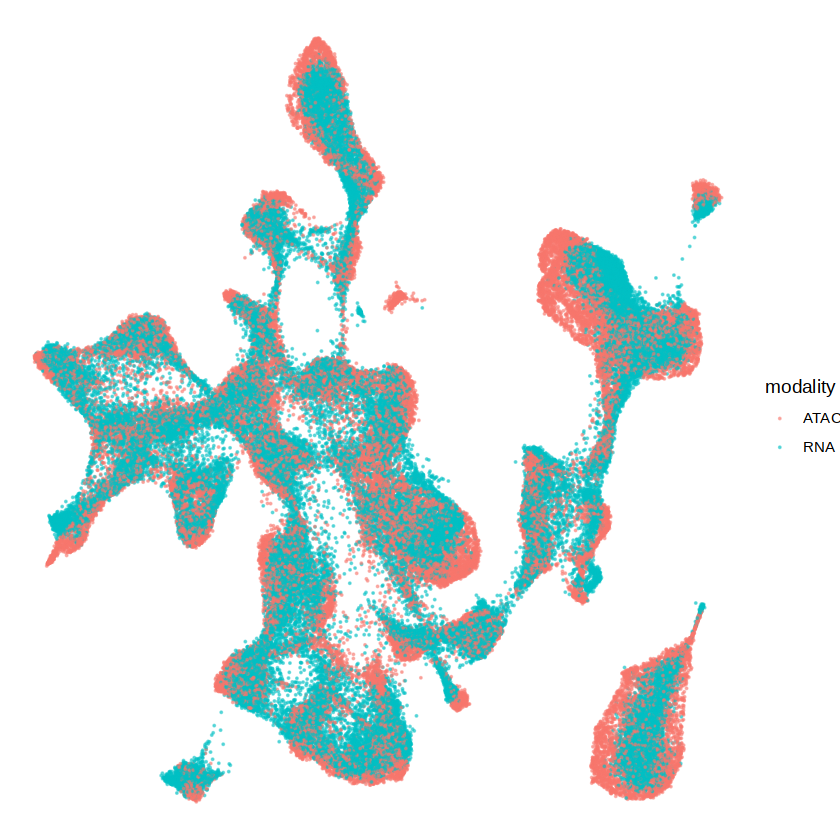

In [11]:
ggplot(CCA_umap[order(sample(1:nrow(CCA_umap))),], aes(UMAP1, UMAP2, col=modality)) + 
    geom_point(size=0.05, alpha=0.5) + 
    theme_void()

In [12]:
cca_rna = CCA_embeddings[CCA_umap$modality=='RNA',]
cca_atac = CCA_embeddings[CCA_umap$modality=='ATAC',]

In [13]:
knns <- BiocNeighbors::queryKNN(cca_atac, cca_rna, k = 1, 
    get.index = TRUE, get.distance = TRUE)

In [14]:
mapped_atac = rownames(cca_atac)[as.vector(knns$index)]#t(apply(knns$index, 1, function(x) rownames(cca_atac)))
mapped_distance = as.vector(knns$distance)

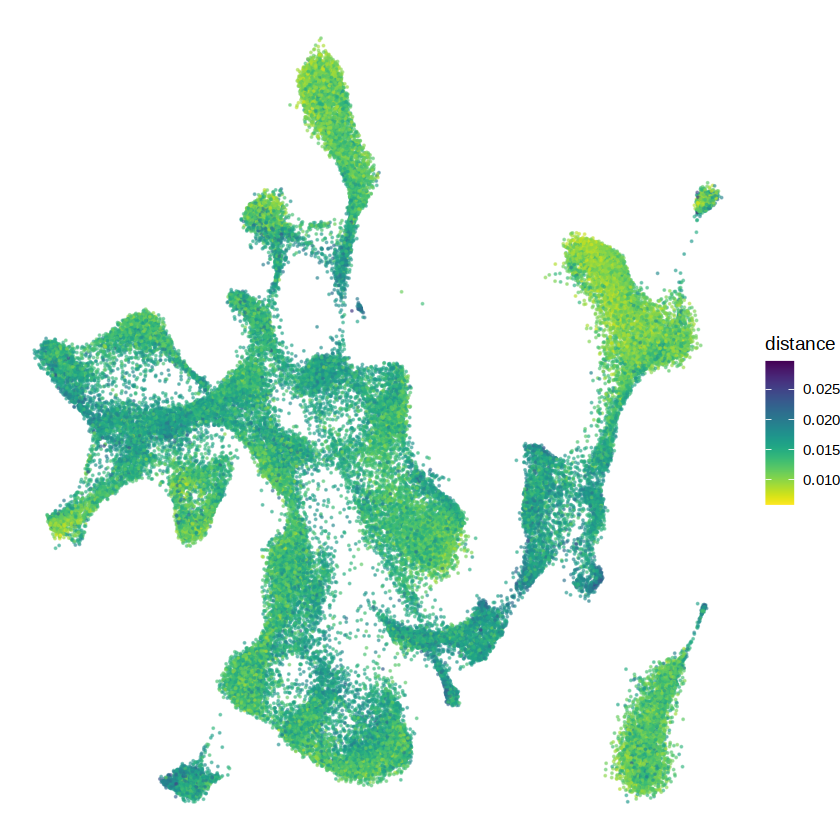

In [15]:
ggplot(CCA_umap[modality=='RNA'][,distance:=mapped_distance], aes(UMAP1, UMAP2, col=distance)) + 
    geom_point(size=0.05, alpha=0.5) + 
    viridis::scale_color_viridis(begin=1, end=0) + 
    theme_void()

In [16]:
mapping = data.table(RNA = gsub('RNA_', '', rownames(cca_rna)),
                     ATAC_mapped = gsub('ATAC_', '', mapped_atac),
                     distance_mapped = mapped_distance)

In [17]:
length(unique(mapping$ATAC_mapped))

[1] 15798

In [18]:
head(mapping)

RNA,ATAC_mapped,distance_mapped
<chr>,<chr>,<dbl>
E7.5_rep1#AAACAGCCAAACTCAT-1,E7.75_rep1#ATTGCGCCAATTTAGC-1,0.01669386
E7.5_rep1#AAACAGCCACAACCTA-1,E7.5_rep1#CAGTACCCAGGTATTT-1,0.01165297
E7.5_rep1#AAACAGCCATCCTGAA-1,E7.5_rep2#CTCCTAATCAATGAGG-1,0.01284157
E7.5_rep1#AAACAGCCATGCTATG-1,E7.5_rep1#TAATCCGCAGCTTAAT-1,0.01248116
E7.5_rep1#AAACATGCAACCTGGT-1,E7.5_rep2#TTCAACCGTCACCTAT-1,0.01381878
E7.5_rep1#AAACATGCAATGAATG-1,E7.5_rep2#CTACGAAGTCCTCCAA-1,0.01277183


In [ ]:
# Seurat multicore
library(future)
plan("multicore", workers = 12)
options(future.globals.maxSize = 50000 * 1024^2) # Use up to 50 Gb of RAM

# CCA integration
CCA = RunCCA(
  rna.seurat,
  atac.seurat,
  standardize = TRUE,
  num.cc = 50
)

In [ ]:
CCA_embeddings = CCA@reductions$cca@cell.embeddings

In [ ]:
# create umap
CCA_umap = uwot::umap(CCA_embeddings, n_neighbors = 40, min_dist = 0.4, metric="cosine", verbose=FALSE)
CCA_umap = as.data.table(CCA_umap, keep.rownames=T) %>%
    setnames(c('cell', 'UMAP1', 'UMAP2')) %>%
    .[,`:=`(modality=cell %>% str_split('_') %>% map_chr(1),
            cell=paste0(cell %>% str_split('_') %>% map_chr(2),
                       '_',
                       cell %>% str_split('_') %>% map_chr(3)))]
head(CCA_umap)

In [ ]:
ggplot(CCA_umap[order(sample(1:nrow(CCA_umap))),], aes(UMAP1, UMAP2, col=modality)) + 
    geom_point(size=0.05, alpha=0.5) + 
    theme_void()

In [ ]:
cca_rna = CCA_embeddings[CCA_umap$modality=='RNA',]
cca_atac = CCA_embeddings[CCA_umap$modality=='ATAC',]

In [ ]:
knns <- BiocNeighbors::queryKNN(cca_atac, cca_rna, k = 1, 
    get.index = TRUE, get.distance = TRUE)

In [ ]:
mapped_atac = rownames(cca_atac)[as.vector(knns$index)]#t(apply(knns$index, 1, function(x) rownames(cca_atac)))
mapped_distance = as.vector(knns$distance)

In [ ]:
ggplot(CCA_umap[modality=='RNA'][,distance:=mapped_distance], aes(UMAP1, UMAP2, col=distance)) + 
    geom_point(size=0.05, alpha=0.5) + 
    viridis::scale_color_viridis(begin=1, end=0) + 
    theme_void()

In [ ]:
mapping = data.table(RNA = gsub('RNA_', '', rownames(cca_rna)),
                     ATAC_mapped = gsub('ATAC_', '', mapped_atac),
                     distance_mapped = mapped_distance)

In [ ]:
length(unique(mapping$ATAC_mapped))

In [ ]:
head(mapping)

### Data transfer instead

In [19]:
# Seurat multicore
library(future)
plan("multicore", workers = 24)
options(future.globals.maxSize = 80000 * 1024^2) # Use up to 50 Gb of RAM

In [ ]:
# Identify anchors
transfer.anchors <- FindTransferAnchors(reference = rna.seurat, 
                                        query = atac.seurat, 
                                        features = VariableFeatures(object = rna.seurat),
                                        reference.assay = "RNA", 
                                        query.assay = "ATAC", 
                                        reduction = "cca",
                                        k.anchor = 10)

Warning message in RunCCA.Seurat(object1 = reference, object2 = query, features = features, :
“Running CCA on different assays”
Running CCA

Merging objects

Finding neighborhoods

Finding anchors

	Found 85523 anchors

Filtering anchors



In [ ]:
saveRDS(transfer.anchors, file.path(io$outdir, 'transfer_anchors_k15.rds'))

In [ ]:
transfer.anchors

In [ ]:
# Get ATAC LSI --> this is not working for adding imputation
ATAC_LSI = fread(io$ATAC_LSI)[match(gsub('ATAC_', '', colnames(atac.seurat)), cell),] %>% 
    .[,cell:=paste0('ATAC_', cell)] %>% 
    as.data.frame() %>%
    tibble::column_to_rownames('cell') %>% as.matrix()
#ArchRProject@reducedDims$IterativeLSI$svd = ATAC_LSI
#atac.seurat[["lsi"]] = addreducedDims etc

In [ ]:
summary(rownames(ATAC_LSI) == colnames(atac.seurat))

In [ ]:
atac.seurat[['LSI']] = CreateDimReducObject(
  embeddings = ATAC_LSI,
  assay = 'ATAC',
  key = 'LSI_')

In [ ]:
genes.use = VariableFeatures(object = rna.seurat)
refdata <- GetAssayData(rna.seurat, assay = "RNA", slot = "data")[genes.use, ]
imputation <- TransferData(anchorset = transfer.anchors, 
                           refdata = refdata,
                           
    weight.reduction = atac.seurat[["LSI"]], dims = 2:30) # which dims?


In [ ]:
atac.seurat[["RNA"]] <- imputation

In [ ]:
coembed <- merge(x = rna.seurat, y = atac.seurat)
coembed <- ScaleData(coembed, features = genes.use, do.scale = FALSE)
coembed <- RunPCA(coembed, features = genes.use, verbose = FALSE)
coembed <- RunUMAP(coembed, dims = 1:30)

DimPlot(coembed, group.by = c("orig.ident"))

In [ ]:
genes.use = VariableFeatures(object = rna.seurat)
refdata <- GetAssayData(rna.seurat, assay = "RNA", slot = "data")[genes.use, ]
imputation <- TransferData(anchorset = transfer.anchors, 
                           refdata = refdata,
                           
    weight.reduction = 'CCA', dims = 2:30) # which dims?


In [ ]:
atac.seurat[["RNA"]] <- imputation

In [ ]:
coembed <- merge(x = rna.seurat, y = atac.seurat)
coembed <- ScaleData(coembed, features = genes.use, do.scale = FALSE)
coembed <- RunPCA(coembed, features = genes.use, verbose = FALSE)
coembed <- RunUMAP(coembed, dims = 1:30)

DimPlot(coembed, group.by = c("orig.ident"))

In [53]:
head(transfer.anchors@object.list[[1]]@reductions$cca@cell.embeddings)

,CC_1,CC_2,CC_3,CC_4,CC_5,CC_6,CC_7,CC_8,CC_9,CC_10,⋯,CC_21,CC_22,CC_23,CC_24,CC_25,CC_26,CC_27,CC_28,CC_29,CC_30
RNA_ E7.5_rep1#AAACAGCCAAACTCAT-1_reference,0.0004672157,0.0038648770,2.124521e-03,0.003584353,0.0021322718,0.003570502,0.001963952,0.0010492283,0.001280393,0.0016349290,⋯,0.001855467,0.0015616935,0.0019096150,0.0009012582,0.0013173404,0.002149525,0.0048122327,0.0009697026,0.006281472,0.0007088528
RNA_ E7.5_rep1#AAACAGCCACAACCTA-1_reference,-0.0028611459,0.0020974203,5.648701e-03,0.010116215,-0.0024152137,-0.004889683,-0.002321547,-0.0026926626,-0.002408891,0.0009429106,⋯,-0.000366651,0.0009877972,-0.0047827287,0.0006995154,0.0001475858,-0.001904959,-0.0057084786,-0.0070250634,0.001451537,0.0023551416
RNA_ E7.5_rep1#AAACAGCCATCCTGAA-1_reference,0.0010025546,0.0007171335,2.003180e-03,0.001077473,0.0033900052,0.006215214,0.001721068,-0.0010492109,-0.002231882,-0.0013122366,⋯,0.001931145,-0.0044944229,-0.0002549402,0.0050057647,0.0019921537,0.004561759,0.0028512133,0.0058941456,-0.001507002,0.0104989131
RNA_ E7.5_rep1#AAACAGCCATGCTATG-1_reference,0.0014101627,0.0054647586,9.447685e-04,0.002716722,0.0002740481,0.005587120,0.002959445,-0.0011954561,0.002634480,0.0029575811,⋯,0.005930062,-0.0006480693,0.0005242214,-0.0033720110,-0.0004522357,-0.001269271,-0.0009743175,0.0009778322,0.001277017,-0.0009980526
RNA_ E7.5_rep1#AAACATGCAACCTGGT-1_reference,-0.0028436396,-0.0014043054,9.635015e-05,0.001866778,-0.0003195487,0.004385751,-0.001137852,0.0000822512,-0.002631600,0.0008187182,⋯,-0.005116422,-0.0046140221,-0.0032594781,0.0003756262,0.0023052044,-0.002975759,0.0051138695,0.0013303062,0.002024167,0.0011674399
RNA_ E7.5_rep1#AAACATGCAATGAATG-1_reference,0.0031564782,0.0020658405,-6.545282e-04,0.001519736,0.0077409299,0.005990231,-0.000982955,-0.0026172628,-0.005382174,-0.0021079508,⋯,-0.002814294,0.0032292971,0.0051674896,-0.0054417517,-0.0010671405,0.001617851,0.0024987799,0.0025559849,0.008066841,-0.0109268115


In [54]:
CCA_embeddings = transfer.anchors@object.list[[1]]@reductions$cca@cell.embeddings

In [55]:
# create umap
CCA_umap = uwot::umap(CCA_embeddings, n_neighbors = 40, min_dist = 0.4, metric="cosine", verbose=FALSE)
CCA_umap = as.data.table(CCA_umap, keep.rownames=T) %>%
    setnames(c('cell', 'UMAP1', 'UMAP2')) %>%
    .[,`:=`(modality=cell %>% str_split('_') %>% map_chr(1),
            cell=paste0(cell %>% str_split('_') %>% map_chr(2),
                       '_',
                       cell %>% str_split('_') %>% map_chr(3)))]
head(CCA_umap)

cell,UMAP1,UMAP2,modality
<chr>,<dbl>,<dbl>,<chr>
E7.5_rep1#AAACAGCCAAACTCAT-1,-2.8984005,-2.659550,RNA
E7.5_rep1#AAACAGCCACAACCTA-1,-10.3848047,-9.365734,RNA
E7.5_rep1#AAACAGCCATCCTGAA-1,-1.4876441,1.562489,RNA
E7.5_rep1#AAACAGCCATGCTATG-1,-3.6528902,-3.449501,RNA
E7.5_rep1#AAACATGCAACCTGGT-1,-10.1356544,12.486561,RNA
E7.5_rep1#AAACATGCAATGAATG-1,0.1317133,-0.549135,RNA


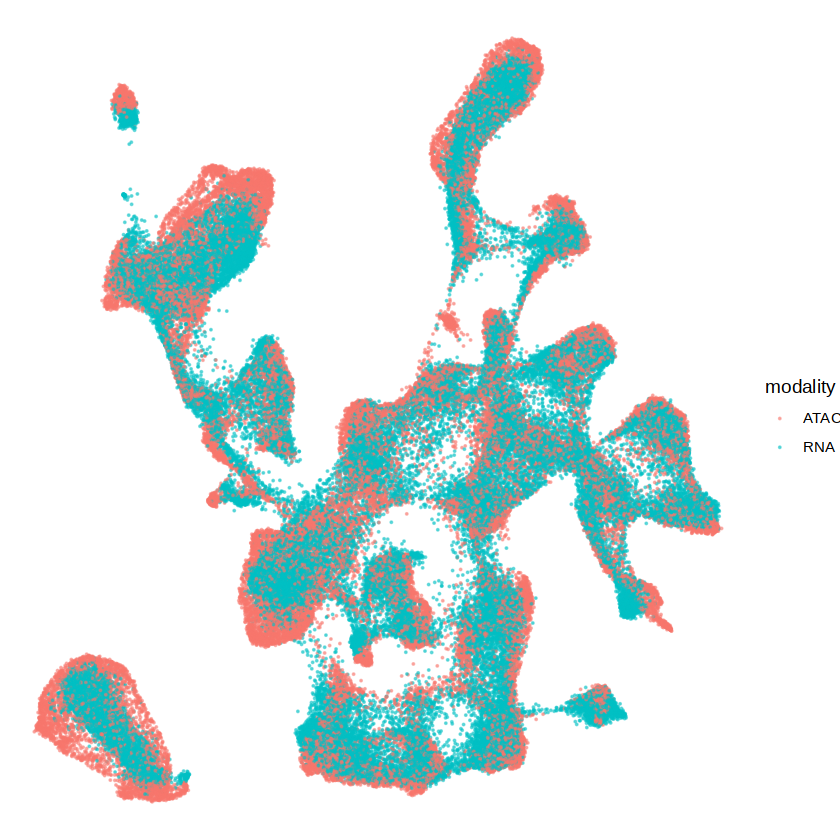

In [56]:
ggplot(CCA_umap[order(sample(1:nrow(CCA_umap))),], aes(UMAP1, UMAP2, col=modality)) + 
    geom_point(size=0.05, alpha=0.5) + 
    theme_void()